In [1]:
import os
import glob
import random
import warnings
import numpy as np
from scipy import io
from tqdm import tqdm


from utils.plots import *
from utils.data import *
from utils.stats_perform import *
import utils.drl as utils
from utils.path import PathConfig,FigureWithData,save_figure_pdf
from rl.agent import *
import rl.plots as rlplt

seed_value=1234
random.seed(seed_value)
np.random.seed(seed_value)
warnings.filterwarnings("ignore")


fig_dir = os.path.join('figures', 'figure_6')
data_fig_dir = os.path.join('data', 'source_data', 'figure_6')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)




In [2]:
paths = PathConfig()
save_dir = paths.save_dir
g_dir = paths.g_dir

groups = ['control','lesion']
var_names = ['input_fr','da_conc','d1_occ','d2_occ']
colors_g = ['black','red','purple']
tr_rew = ['reward','omission']
tr_cs = ['90%','50%','10%']
f_size = 12
alpha_p = .05
max_trials = 200
n_samp = 3900
nf = [45,44]

## Analysis of biophysical simulations

This notebook reproduces the analysis performed on the output variables from the biophysical simulation.

**Note:** To plot and use the present notebook the user needs to download the data inside `raw_data` folder of the OSF repository. Look at  `download_data` for the code to do this.


### Additional information on data format: 

**Trial types**

- `1`:  90% rewarded
- `2`:  90% omission
- `3`:  50% rewarded
- `4`:  50% omission
- `5`:  10% rewarded
- `6`:  10% omission

Output variables from loading: 
- `mu_var_cells`: (N groups) x(N variables) x (N trialtypes) x (N reward types) x (N cells) x (N samples per trial) 
- `single_trial_var_cells`: (N groups) x(N variables) x (N trialtypes) x (N reward types) x (N cells) x (N samples per trial) x (N trials)

Where: 
- N groups = 2  (control, lesion)
- N variables = 4 (input firing rate, DA concentration, D1 occupancy, D2 occupancy)
- N trialtypes = 6 (90% reward, 50% reward, 10% reward)
- N reward types = 2 (rewarded, omission)
- N cells = 45, 44 for each group
- N samples per trial = 3900 (`n_samp`)

In [3]:

id_trial_plot = [[1,3,5],[2,4,6]] 
mu_var_cells = np.empty((len(groups),len (var_names),len(id_trial_plot),len(id_trial_plot[0]),45,n_samp))
single_trial_var_cells =  np.empty((len(groups),len(var_names),len(id_trial_plot),len(id_trial_plot[0]),45,n_samp,max_trials))
for ig in np.arange(len(groups)):
    data_path = os.path.join(g_dir,'raw_data', groups[ig])
    file_list = glob.glob(data_path + "/*.pickle")
    print('loading ' + groups[ig])
    file_list = file_list[:nf[ig]]
    for (id_unit) in  tqdm(range(len(file_list))):
        with open(file_list[id_unit], 'rb') as handle:
            unit = pickle.load(handle)
        trial_types, trial_names = unit['data']['TrialTypes'], unit['data']['TrialNames']
        temp = np.asarray(unit['simulation_results']['time_ax'])
        ind = np.unravel_index(np.argmax(temp, axis=None), temp.shape)
        for iv in np.arange(len(var_names)):
            var_name = var_names[iv]
            var = np.asarray(unit["simulation_results"][var_name])
            # exec('var = np.asarray(unit["simulation_results"].' + var_name + ')')
            time_ax = np.asarray(unit['simulation_results']['time_ax'])[:,ind[1]]
            for ir in np.arange(len(id_trial_plot)):
                for i in np.arange(len(id_trial_plot[ir])):
                    id_trials = np.argwhere(np.isin(trial_types, id_trial_plot[ir][i])==1)[:,0]
                    id_trials = id_trials[id_trials<max_trials]
                    var_trials = var[:,id_trials]
                    var_trials[var_trials<=0] = np.nan
                    if iv==1:
                        var_trials[var_trials>3000]=np.nan # TODO
                    elif iv>=2:
                        var_trials[var_trials>1]=np.nan
                    mu_var = np.nanmean(var_trials,axis=1)
                    mu_var_cells[ig,iv,ir,i,id_unit,:]=mu_var
                    single_trial_var_cells[ig,iv,ir,i,id_unit,:,0:var_trials.shape[1]]= var_trials
                    ids_ = [np.argwhere(ii==0).flatten() for ii in single_trial_var_cells[ig,iv,ir,i,id_unit,:,:].T]
                    for (ii,ids) in enumerate(ids_):
                        single_trial_var_cells[ig,iv,ir,i,id_unit,ids,ii] = np.nan

loading control


100%|██████████| 45/45 [00:05<00:00,  8.61it/s]


loading lesion


100%|██████████| 44/44 [00:04<00:00,  9.07it/s]


## Figure 6c
Plot mean responses from dopamine biophysical simulations across neurons for each group (*Lesion* : red , *Control* : black)

**Variables plotted:**

*Input to model:*
- `input_fr` : input firing rates from the LHb lesion dataset
  
*Outputs from model:*
- `da_conc`: Dopamine concentration 
- `d1_occ` : D1 receptor occupancy
- `d2_occ`: D2 receptor occupancy

*Note*: The windows of responses differs between the input firing rates (faster timescale) and the rest of variables (slower timescales)

Saved figure to figures/figure_6/figure_6c_input_fr.pdf
Saved data and stats to data/source_data/figure_6/figure_6c_input_fr.txt
Saved figure to figures/figure_6/figure_6c_da_conc.pdf
Saved data and stats to data/source_data/figure_6/figure_6c_da_conc.txt
Saved figure to figures/figure_6/figure_6c_d1_occ.pdf
Saved data and stats to data/source_data/figure_6/figure_6c_d1_occ.txt
Saved figure to figures/figure_6/figure_6c_d2_occ.pdf
Saved data and stats to data/source_data/figure_6/figure_6c_d2_occ.txt


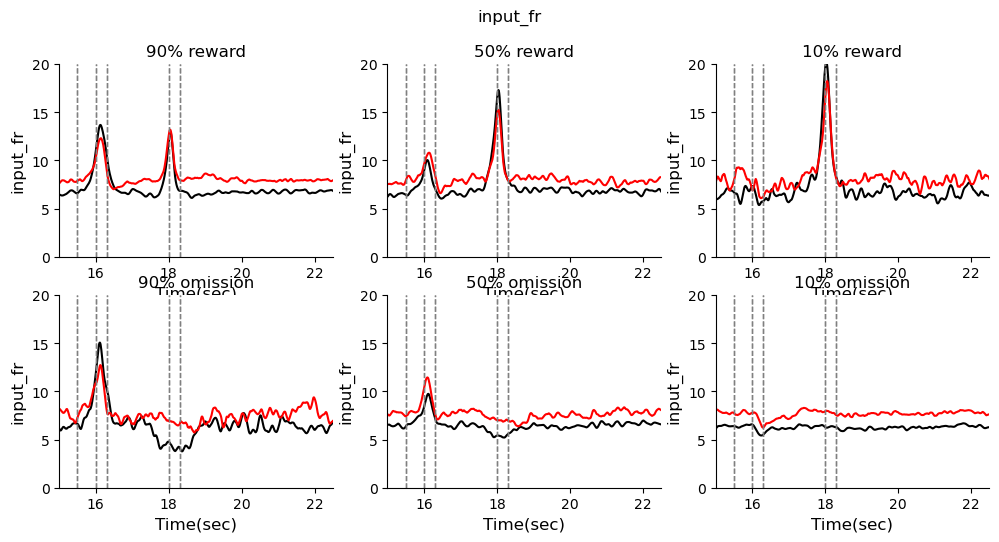

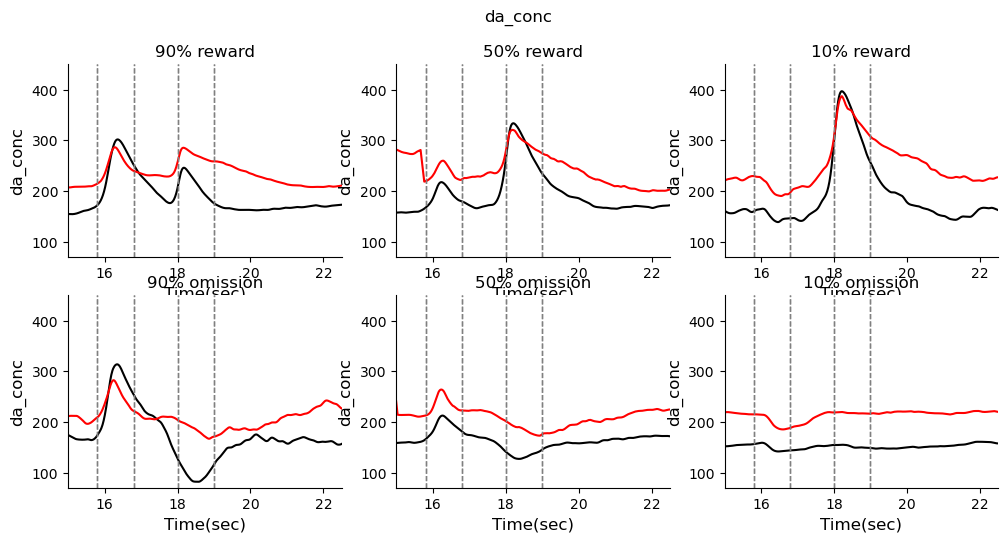

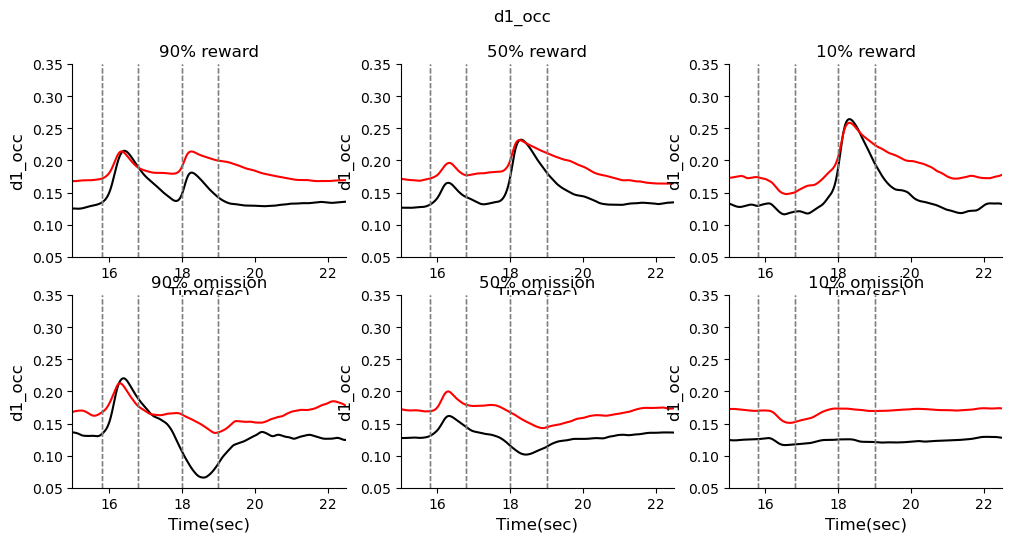

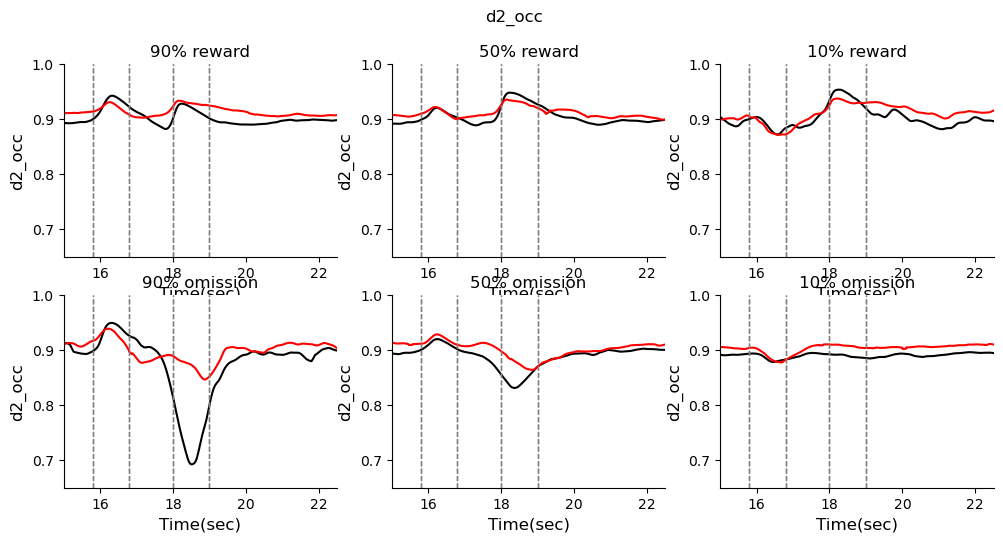

In [4]:
mu_var_cells[mu_var_cells<=0]=np.nan
mu_var_cells[1,:,:,:,4,:]=np.nan # TODO
window_lists = [[ [16,16.3],[18,18.3],[14.5,15.5]], [[15.8,16.8],[18,19],[5.,10.]]]  # Windows of responses 
yl = [[0 , 20],[70 ,450],[.05, .35],[.65,1]] 
xl = [[5.,30],[5,30],[5,30],[5,30]]
idwindow = [0,1,1,1]
for iv in  np.arange(4):
    window_list = window_lists[idwindow[iv]]
    fig, ax= plt.subplots(2,3,figsize=(12, 5.5))    
    fig_data_6c_iv = FigureWithData(fig)

    for ig in np.arange(len(groups)):
        for ir in np.arange(len(id_trial_plot)):
            for i in np.arange(len(id_trial_plot[ir])):
                tt = mu_var_cells[ig,iv,ir,i,:,:]
                temp = smooth(np.nanmean(tt,axis=0),10)
                ax[ir,i].plot(time_ax,temp,color = colors_g[ig])
                [[ax[ir,i].plot([iw[ii],iw[ii]],[yl[iv][0],yl[iv][1]],'--',color='grey',linewidth=1) for ii in range(len(iw))] for iw in window_list]
                ax[ir,i].set_xlim(xl[iv][0],xl[iv][1])
                ax[ir,i].set_ylim(yl[iv][0],yl[iv][1])
                plot_config(ax[ir,i],'Time(sec)',var_names[iv],f_size,False)
                title_(ax[ir,i],tr_cs[i]+ ' '+ tr_rew[ir])
                ax[ir,i].set_xlim([15,22.5])

                # --- Add the data to the FigureWithData object ---
                panel_name = f"group_{groups[ig]}_reward_{tr_rew[ir]}_cue_{tr_cs[i]}"
                panel_data = np.column_stack((time_ax, temp))
                panel_headers = ['Time_sec', f"{var_names[iv]}_value"]
                fig_data_6c_iv.add_data(
                    panel_name,
                    panel_data,
                    panel_headers
                )
    plt.suptitle(var_names[iv])
    # --- Save the figure and the data for this variable ---
    fig_data_6c_iv.save(
        base_filename=f'figure_6c_{var_names[iv].replace(" ", "_").lower()}',  # Clean filename
        folder_data= data_fig_dir,
        folder_figures= fig_dir
    )
    

## Figure 6 e,f
Compute baselines of the same simulation variables  as above

Code flow:
1. Compute baseline activity on the window of interest `window_base` for each group
2. Plot boxplots of baseline distributions for each group
3. Perform test for: 
    a. normality of distribution 
    b. difference of distributions between control and lesion groups

Output varaible:
- `base_cells`: (N groups) x (N variables) x (N cells)

The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_6/figure_6d_input_fr.pdf
Saved data and stats to data/source_data/figure_6/figure_6d_input_fr.txt
The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_6/figure_6d_da_conc.pdf
Saved data and stats to data/source_data/figure_6/figure_6d_da_conc.txt
The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_6/figure_6d_d1_occ.pdf
Saved data and stats to data/source_data/figure_6/figure_6d_d1_occ.txt
The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_6/figure_6d_d2_occ.pdf
Saved data and stats to data/source_data/figure_6/figure_6d_d2_occ.txt


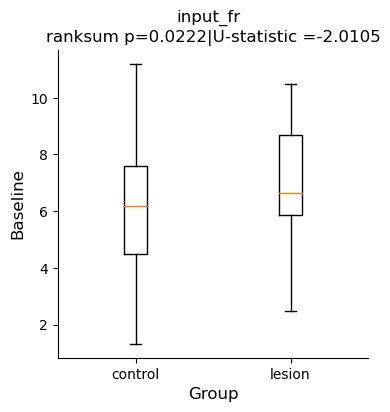

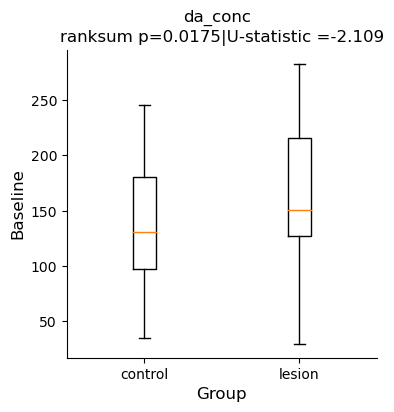

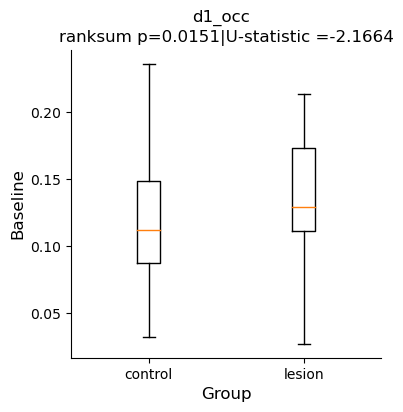

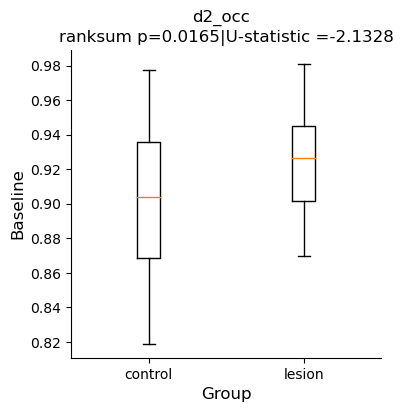

In [6]:
# Compute baselines:
window_base = [14.5,15.5]
base_cells  = np.empty((len(groups),len(var_names),45))
for ig in np.arange(len(groups)):
    for iv in  np.arange(4):
        id_s = np.argwhere(time_ax>window_base[0]).flatten()[0]
        id_e = np.argwhere(time_ax>window_base[1]).flatten()[0]
        var_trials = single_trial_var_cells[ig,iv,:,:,:,id_s:id_e,:].transpose(2,0,1,3,4)
        var_trials = np.reshape(var_trials,(var_trials.shape[0],-1))
        var_trials[var_trials<=0]=np.nan # TODO
        mu_base = np.nanmean(var_trials,axis=1)
        base_cells[ig,iv,:] = mu_base

for iv in np.arange(len(var_names)):
    # Box plot
    fig,ax = plt.subplots(figsize=(4,4))
    var_name = var_names[iv]
    base_g  =  [base_cells[0,iv,~np.isnan(base_cells[0,iv,:])],base_cells[1,iv,~np.isnan(base_cells[1,iv,:])]]
    ax.boxplot([base_g[0],base_g[1]],showfliers=False)
    plot_config(ax,'Group','Baseline',12,False)
    
    xticks_(ax,[1,2],groups)
    fig.suptitle(var_names[iv])
    
    # Statistical test 
    groups_test = [base_g]
    name_suff,name_preff = ['base'], var_names[iv]
    alternative = 'less'
    if iv==0:
        tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = True ,alternative=alternative)
    else:
        tests_pd = get_tests_table(groups_test, name_preff, name_suff,alternative=alternative,tests_pd=tests_pd)
    
    gname = name_preff + '_'+name_suff[0]
    ll = len(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] == name_preff +'_all')].pvals.to_numpy()[0])
    ss = np.sum(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] ==name_preff +'_all')].pvals.to_numpy()[0]>.05)
    if ll>ss:
        pvals = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gname)].pvals.to_numpy()[0]
        stats_p = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gname)].stats.to_numpy()[0]  
        stats_n = tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == gname)].stat_name.to_numpy()[0]  
        test_n = 'ranksum'
    else:
        pvals = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] ==gname)].pvals.to_numpy()[0]
        stats_p = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] == gname)].stats.to_numpy()[0]   
        stats_n = tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] == gname)].stat_name.to_numpy()[0]  
        test_n = 't-test'     
    title_(ax, test_n +' p='+ str(np.round(10000*pvals)/10000) +'|'+stats_n+ ' ='+ str(np.round(10000*stats_p)/10000))     


    # 1. Create the wrapper
    fig_data_baseline_iv = FigureWithData(fig)

    # 2. Save baseline data
    # Each row = (Control_value, Learning_value)
    max_n = max(len(base_g[0]), len(base_g[1]))
    # Pad shorter group with NaN to match length
    base_g_padded = np.full((max_n, 2), np.nan)
    base_g_padded[:len(base_g[0]), 0] = base_g[0]
    base_g_padded[:len(base_g[1]), 1] = base_g[1]

    fig_data_baseline_iv.add_data(
        "Baseline values per group",
        base_g_padded,
        ['Control_group', 'Lesion_group']
    )

    # 3. Save the stat
    # (already extracted: pvals, stats_p, stats_n, test_n)
    stat_array = np.array([[pvals, stats_p]])
    stat_headers = ['p_value', 'test_statistic']

    fig_data_baseline_iv.add_stats(
        f"Statistical test ({test_n}, {stats_n})",
        stat_array,
        stat_headers
    )

    # 4. Save everything
    fig_data_baseline_iv.save(
        base_filename=f'figure_6d_{var_names[iv].replace(" ", "_").lower()}',
        folder_data= data_fig_dir,
        folder_figures= fig_dir
    )
tests_pd.to_excel("analysis/stats/Fig6.xlsx")